# Atividade Aula 38 - 30/09/2025


Alan Diek da Silva Guimarães


## CART do zero


In [11]:
# === Utilitarios mínimos (acurácia, dataset de exemplo e plot) ===
import numpy as np
import matplotlib.pyplot as plt

def accuracy(y_true, y_pred):
    return float((y_true == y_pred).mean())

def make_moons(n=600, noise=0.25, seed=0):
    rng = np.random.RandomState(seed)
    angles = rng.rand(n//2) * np.pi*1.2
    x1 = np.c_[np.cos(angles), np.sin(angles)]
    x2 = np.c_[np.cos(angles), -np.sin(angles)]+[1.0, -0.5]#x1 + [1.0, -0.5]
    X = np.vstack([x1, x2])
    y = np.r_[np.zeros(n//2, dtype=int), np.ones(n//2, dtype=int)]
    X += rng.normal(scale=noise, size=X.shape)
    return X, y

def plot_decision_boundary(model, X, y, h=0.03, proba=False, title="Fronteira de decisão"):
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    if proba and hasattr(model, "predict_proba"):
        Z = model.predict_proba(grid)
        if Z.ndim == 2 and Z.shape[1] > 1: Z = Z[:,1]
    else:
        Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.7)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k',alpha=0.3)
    plt.title(title); plt.xlabel("x1"); plt.ylabel("x2")
    plt.show()


In [12]:

import numpy as np

def class_probs(y, n_classes=None):
    y = y.astype(int)
    if n_classes is None:
        if y.size == 0:
            return np.array([])
        n_classes = int(np.max(y)) + 1
    counts = np.bincount(y, minlength=n_classes).astype(float)
    s = counts.sum()
    return counts / s if s > 0 else counts

def gini(y):
    p = class_probs(y); return 1.0 - np.sum(p**2)

def entropy(y, eps=1e-12):
    p = class_probs(y); return -np.sum(p * np.log(p + eps))

def impurity(y, criterion="gini"):
    return gini(y) if criterion == "gini" else entropy(y)

def candidate_thresholds(x, max_candidates=50):
    x = np.asarray(x); uniq = np.unique(x)
    if uniq.size < 2: return np.array([])
    if uniq.size > max_candidates:
        qs = np.linspace(0, 1, max_candidates + 2)[1:-1]
        thr = np.unique(np.quantile(x, qs))
    else:
        thr = (uniq[:-1] + uniq[1:]) / 2.0
    return thr

def split_on_threshold(X, y, j, thr):
    xj = X[:, j]
    L = xj <= thr
    R = ~L
    return L, R

def weighted_impurity(yL, yR, criterion="gini"):
    m = yL.size + yR.size
    if m == 0: return 0.0
    return (yL.size * impurity(yL, criterion) + yR.size * impurity(yR, criterion)) / m

def best_split(X, y, *, criterion="gini", max_features=None, rng=None, max_candidates=50, stats=None):

    m, n = X.shape
    parent = impurity(y, criterion)
    if m == 0 or parent <= 0.0:
        return {"gain": 0.0, "feat": None, "thr": None}

    feats = np.arange(n)
    if max_features is not None:
        if isinstance(max_features, str) and max_features == "sqrt":
            k = max(1, int(np.sqrt(n)))
        elif isinstance(max_features, int):
            k = max(1, min(n, max_features))
        else:
            k = n
        if rng is None: rng = np.random.RandomState(0)
        feats = rng.choice(n, size=k, replace=False)

    best = {"gain": 0.0, "feat": None, "thr": None}
    cands = 0; valid = 0
    for j in feats:
        thrs = candidate_thresholds(X[:, j], max_candidates=max_candidates)
        cands += thrs.size
        for t in thrs:
            L, R = split_on_threshold(X, y, j, t)
            if not L.any() or not R.any():
                continue
            valid += 1
            gain = parent - weighted_impurity(y[L], y[R], criterion)
            if gain > best["gain"]:
                best = {"gain": float(gain), "feat": int(j), "thr": float(t)}
    if stats is not None:
        stats['cands'] = stats.get('cands', 0) + int(cands)
        stats['valid'] = stats.get('valid', 0) + int(valid)
    return best

def _leaf(y, n_classes):
    return {"type": "leaf", "proba": class_probs(y, n_classes=n_classes)}

def build_tree(X, y, depth, *, max_depth=8, min_samples_split=2,
               criterion="gini", max_features=None, rng=None, max_candidates=50, stats=None, n_classes=None):
    # Ensurse an effing fixed class dimension for the whole tree
    if n_classes is None:
        n_classes = int(np.max(y)) + 1 if y.size else 0

    if (depth >= max_depth) or (X.shape[0] < min_samples_split) or (impurity(y, criterion) == 0.0):
        return _leaf(y, n_classes)

    split = best_split(X, y, criterion=criterion, max_features=max_features, rng=rng,
                       max_candidates=max_candidates, stats=stats)
    if split["feat"] is None:
        return _leaf(y, n_classes)

    j, t = split["feat"], split["thr"]
    L, R = split_on_threshold(X, y, j, t)
    left = build_tree(X[L], y[L], depth+1, max_depth=max_depth, min_samples_split=min_samples_split,
                      criterion=criterion, max_features=max_features, rng=rng,
                      max_candidates=max_candidates, stats=stats, n_classes=n_classes)
    right = build_tree(X[R], y[R], depth+1, max_depth=max_depth, min_samples_split=min_samples_split,
                       criterion=criterion, max_features=max_features, rng=rng,
                       max_candidates=max_candidates, stats=stats, n_classes=n_classes)
    return {"type": "node", "feat": int(j), "thr": float(t), "left": left, "right": right}

def predict_proba_row(node, x):
    while node["type"] != "leaf":
        node = node["left"] if x[node["feat"]] <= node["thr"] else node["right"]
    return node["proba"]

def predict_proba(tree, X):
    return np.vstack([predict_proba_row(tree, x) for x in X])

def predict(tree, X):
    P = predict_proba(tree, X); return np.argmax(P, axis=1)

class DecisionTree:
    def __init__(self, max_depth=8, min_samples_split=2, criterion="gini",
                 max_features=None, random_state=0, max_candidates=50):
        self.max_depth = max_depth; self.min_samples_split = min_samples_split
        self.criterion = criterion; self.max_features = max_features
        self.random_state = random_state; self.max_candidates = max_candidates
        self.rng_ = np.random.RandomState(random_state); self.tree_ = None
        self.n_classes_ = None
        self.stats_ = {}

    def fit(self, X, y):
        self.n_classes_ = int(np.max(y)) + 1 if y.size else 0
        self.stats_ = {}
        self.tree_ = build_tree(
            X, y, depth=0,
            max_depth=self.max_depth, min_samples_split=self.min_samples_split,
            criterion=self.criterion, max_features=self.max_features, rng=self.rng_,
            max_candidates=self.max_candidates, stats=self.stats_, n_classes=self.n_classes_
        )
        return self

    def predict_proba(self, X): return predict_proba(self.tree_, X)
    def predict(self, X): return np.argmax(self.predict_proba(X), axis=1)

def trace_path(tree, x):
    steps = []; node = tree
    while node["type"] != "leaf":
        j, t = node["feat"], node["thr"]; go_left = x[j] <= t
        steps.append((int(j), float(t), bool(go_left)))
        node = node["left"] if go_left else node["right"]
    return steps, node["proba"]

def pretty_print(node, depth=0):
    import numpy as _np
    indent = "  " * depth
    if node["type"] == "leaf":
        print(f"{indent}Leaf proba={_np.round(node['proba'], 3)}")
    else:
        j, t = node["feat"], node["thr"]
        print(f"{indent}if x[{j}] <= {t:.4f}:")
        pretty_print(node["left"], depth+1)
        print(f"{indent}else:  # x[{j}] > {t:.4f}")
        pretty_print(node["right"], depth+1)


In [13]:

# ===  Passo-a-passo do algoritmo (dataset minúsculo) ===
import numpy as np

X_small = np.array([
    [2.0, 3],
    [2.5, 2],
    [2.7, 5],
    [3.0, 4],
    [3.2, 2],
    [3.6, 6],
], dtype=float)
y_small = np.array([0,0,1,1,0,1], dtype=int)

print("Impureza (Gini) na raiz:", round(impurity(y_small, "gini"), 4))

stats = {}
split = best_split(X_small, y_small, criterion="gini", stats=stats, max_candidates=50)
print("Melhor split:", split)
print("Candidatos avaliados:", stats.get('cands', 0), "| válidos:", stats.get('valid', 0))

tree_small = build_tree(X_small, y_small, depth=0, max_depth=2, criterion="gini", stats={})
pretty_print(tree_small)

steps, proba = trace_path(tree_small, X_small[0])
print("Caminho (feat, thr, vai_esq?):", steps)
print("Probabilidades na folha:", np.round(proba, 3))


Impureza (Gini) na raiz: 0.5
Melhor split: {'gain': 0.5, 'feat': 1, 'thr': 3.5}
Candidatos avaliados: 9 | válidos: 9
if x[1] <= 3.5000:
  Leaf proba=[1. 0.]
else:  # x[1] > 3.5000
  Leaf proba=[0. 1.]
Caminho (feat, thr, vai_esq?): [(1, 3.5, True)]
Probabilidades na folha: [1. 0.]


Acurácia (treino (o todo é treino)): 0.985


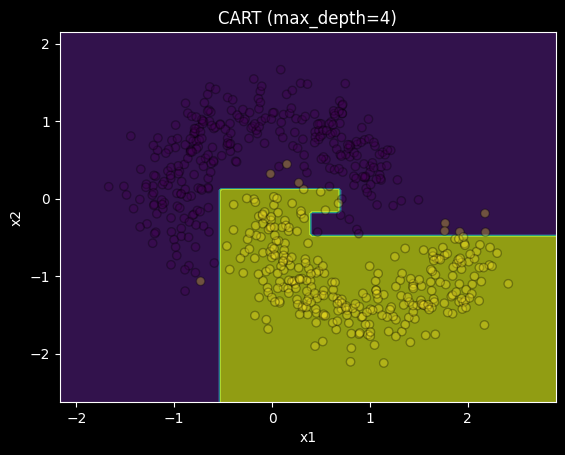

In [14]:

# ===  Demonstração rápida (moons)  ===
X, y = make_moons(n=600, noise=0.25, seed=32)
model = DecisionTree(max_depth=4, criterion="gini", random_state=12).fit(X, y)


print("Acurácia (treino (o todo é treino)):", accuracy(y, model.predict(X)))
#print("Stats (candidatos/validos):", model.stats_)
plot_decision_boundary(model, X, y, title="CART (max_depth=4)")


In [15]:
pretty_print(model.tree_)

if x[1] <= -0.1679:
  if x[0] <= -0.4298:
    if x[0] <= -0.5264:
      if x[1] <= -1.0114:
        Leaf proba=[0.5 0.5]
      else:  # x[1] > -1.0114
        Leaf proba=[1. 0.]
    else:  # x[0] > -0.5264
      Leaf proba=[0. 1.]
  else:  # x[0] > -0.4298
    if x[1] <= -0.4642:
      Leaf proba=[0. 1.]
    else:  # x[1] > -0.4642
      if x[0] <= 0.3965:
        Leaf proba=[0. 1.]
      else:  # x[0] > 0.3965
        Leaf proba=[0.5 0.5]
else:  # x[1] > -0.1679
  if x[1] <= 0.1303:
    if x[0] <= -0.5215:
      Leaf proba=[1. 0.]
    else:  # x[0] > -0.5215
      if x[0] <= 0.6961:
        Leaf proba=[0. 1.]
      else:  # x[0] > 0.6961
        Leaf proba=[1. 0.]
  else:  # x[1] > 0.1303
    if x[1] <= 0.4456:
      if x[1] <= 0.4389:
        Leaf proba=[0.963 0.037]
      else:  # x[1] > 0.4389
        Leaf proba=[0.5 0.5]
    else:  # x[1] > 0.4456
      Leaf proba=[1. 0.]



## Exercícios
1. Calcule explicitamente o ganho (Gini) para todos os thresholds possíveis de `x1` em `X_small` e confirme o melhor split.
2. Troque `criterion="entropy"` e veja se o primeiro split muda neste conjunto minúsculo.
3. Varra `max_depth` de 1 a 16 para um dataset tipo `moons` e plote Acurácia (treino) vs profundidade. Identifique subajuste/sobreajuste.
4. Verifique se existe diferença no plot de acurácia trocando de critério entre gini e entropy.
5. E os pinguins? Cheque como uma árvore classifica as espécies de pinguins e utilize um valor de max_depth que achar adequado.


# Exercícios 

1. Calcule explicitamente o ganho (Gini) para todos os thresholds possíveis de `x1` em `X_small` e confirme o melhor split.

In [ ]:
gini_pai = impurity(y_small, "gini")
x1_vals = X_small[:, 0]
thresholds = [2.25, 2.6, 2.85, 3.1, 3.4]

for thr in thresholds:
    L, R = split_on_threshold(X_small, y_small, 0, thr)
    ganho = gini_pai - weighted_impurity(y_small[L], y_small[R], "gini")
    print(f"Threshold {thr}: ganho = {ganho:.4f}")

Threshold 2.25: ganho = 0.1000
Threshold 2.6: ganho = 0.2500
Threshold 2.85: ganho = 0.0556
Threshold 3.1: ganho = 0.0000
Threshold 3.4: ganho = 0.1000


2. Troque `criterion="entropy"` e veja se o primeiro split muda neste conjunto minúsculo.

In [17]:
split_entropy = best_split(X_small, y_small, criterion="entropy")
print("Melhor split com entropy:", split_entropy)

Melhor split com entropy: {'gain': 0.6931471805589454, 'feat': 1, 'thr': 3.5}


3. Varra `max_depth` de 1 a 16 para um dataset tipo `moons` e plote Acurácia (treino) vs profundidade. Identifique subajuste/sobreajuste.

Profundidade 1: Acurácia = 0.9167
Profundidade 2: Acurácia = 0.9600
Profundidade 3: Acurácia = 0.9717
Profundidade 4: Acurácia = 0.9850
Profundidade 5: Acurácia = 0.9967
Profundidade 6: Acurácia = 0.9983
Profundidade 7: Acurácia = 1.0000
Profundidade 8: Acurácia = 1.0000
Profundidade 9: Acurácia = 1.0000
Profundidade 10: Acurácia = 1.0000
Profundidade 11: Acurácia = 1.0000
Profundidade 12: Acurácia = 1.0000
Profundidade 13: Acurácia = 1.0000
Profundidade 14: Acurácia = 1.0000
Profundidade 15: Acurácia = 1.0000
Profundidade 16: Acurácia = 1.0000


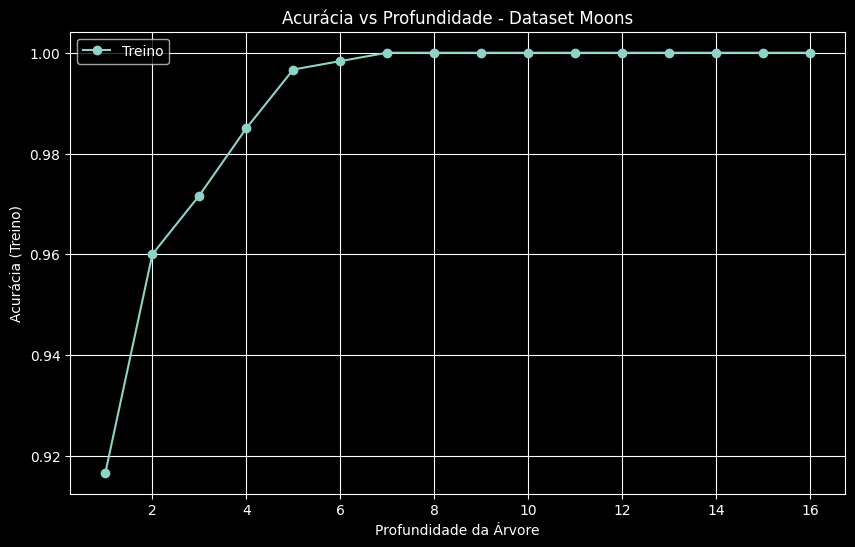

In [18]:
X, y = make_moons(n=600, noise=0.25, seed=32)

train_acc = []
depths = range(1, 17)

for depth in depths:
    model = DecisionTree(max_depth=depth, random_state=12).fit(X, y)
    train_acc.append(accuracy(y, model.predict(X)))
    print(f"Profundidade {depth}: Acurácia = {train_acc[-1]:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(depths, train_acc, 'o-', label='Treino')
plt.xlabel('Profundidade da Árvore')
plt.ylabel('Acurácia (Treino)')
plt.title('Acurácia vs Profundidade - Dataset Moons')
plt.legend()
plt.grid(True)
plt.show()

4. Verifique se existe diferença no plot de acurácia trocando de critério entre gini e entropy.

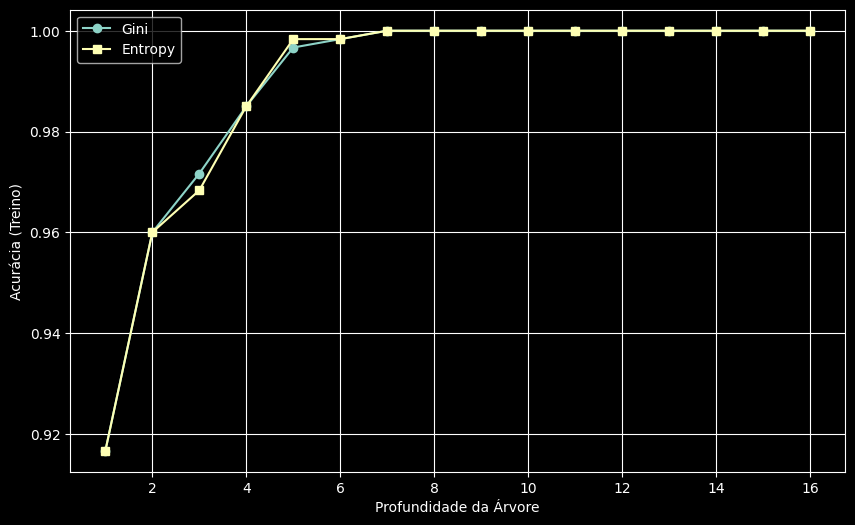

In [19]:
acc_gini = []
acc_entropy = []
depths = range(1, 17)

for depth in depths:
    # Gini
    model_gini = DecisionTree(max_depth=depth, criterion="gini", random_state=12).fit(X, y)
    acc_gini.append(accuracy(y, model_gini.predict(X)))

    # Entropy
    model_entropy = DecisionTree(max_depth=depth, criterion="entropy", random_state=12).fit(X, y)
    acc_entropy.append(accuracy(y, model_entropy.predict(X)))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(depths, acc_gini, 'o-', label='Gini')
plt.plot(depths, acc_entropy, 's-', label='Entropy')
plt.xlabel('Profundidade da Árvore')
plt.ylabel('Acurácia (Treino)')
plt.legend()
plt.grid(True)
plt.show()

5. E os pinguins? Cheque como uma árvore classifica as espécies de pinguins e utilize um valor de max_depth que achar adequado.


Acurácia: 0.9459459459459459


if x[0] <= 42.2706:
  if x[1] <= 15.1000:
    Leaf proba=[0. 0. 1.]
  else:  # x[1] > 15.1000
    if x[1] <= 16.6500:
      Leaf proba=[0.909 0.091 0.   ]
    else:  # x[1] > 16.6500
      Leaf proba=[1. 0. 0.]
else:  # x[0] > 42.2706
  if x[1] <= 16.3000:
    Leaf proba=[0. 0. 1.]
  else:  # x[1] > 16.3000
    if x[0] <= 44.8235:
      Leaf proba=[0.625 0.312 0.062]
    else:  # x[0] > 44.8235
      Leaf proba=[0.041 0.849 0.11 ]


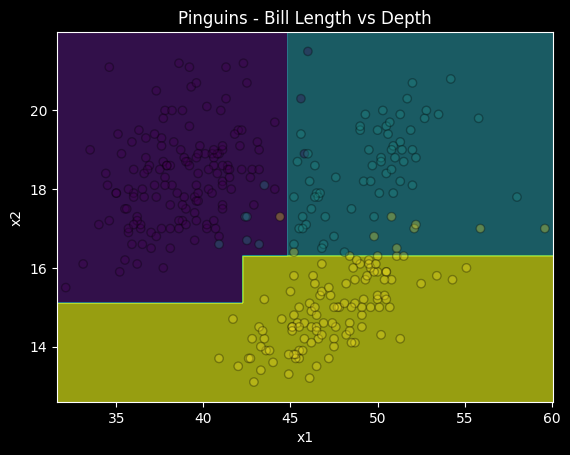

In [23]:
import pandas as pd

penguin_url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
df = pd.read_csv(penguin_url)
df.dropna(inplace=True)

species_map = {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
y = df['species'].map(species_map).values

feature_cols = ['bill_length_mm', 'bill_depth_mm']
X_o = df[feature_cols].values

# Treinar árvore
model = DecisionTree(max_depth=3, random_state=12).fit(X_o, y)
print("\nAcurácia:", accuracy(y, model.predict(X_o)))
print('\n')
# Ver estrutura da árvore
pretty_print(model.tree_)


plot_decision_boundary(model, X_o, y, title="Pinguins - Bill Length vs Depth")

